In [1]:
import os
import glob
import json
import numpy as np
import pandas as pd
from pathlib import Path
from PNW_cmap import PNW_cmap
import matplotlib.pyplot as plt
from vip_slap2_analysis.utils.utils import save_figure
from vip_slap2_analysis.io.session_registry import VIPSessionRegistry
from vip_slap2_analysis.glutamate.summary import GlutamateSummary
from vip_slap2_analysis.utils.utils import normalize

import seaborn as sns
sns.set_style('white')
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
plt.rcParams.update(params)

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
%matplotlib notebook

In [10]:
savepath = r"C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Data_Club\April2026"

In [51]:
cl, cmap, cp = PNW_cmap.get_PNW_cmap('Sailboat', n_colors=4)
cp

[(0.4823529411764706, 0.7372549019607844, 0.8352941176470589),
 (0.8156862745098039, 0.8862745098039215, 0.6862745098039216),
 (0.9607843137254901, 0.8588235294117647, 0.6),
 (0.9098039215686274, 0.611764705882353, 0.5058823529411764)]

In [52]:
cp = cp[::-1]

In [4]:
target_mice = [
    803496,
    804730,804733,810196,
    809047,803121,
    826033,838410,834788
]

registry = VIPSessionRegistry.from_basepath(
    r'\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics'
)

process_df = registry.sessions(
    subject_ids=target_mice,
    exclude_session_types=["expression_check", "volume_imaging"],
    paradigms=["change_detection_passive"],
)

assets = [registry.resolve_assets(row) for _, row in process_df.iterrows()]

print(f"Loaded {len(assets)} session assets")

Loaded 56 session assets


In [5]:
seq_sums = []
seq_pars = []
seq_pos = []
for asset in assets:
    try:
        derived_dir = asset.derived_dir / 'glutamate' /'glutamate_analysis'
        seq_sum = pd.read_csv(os.path.join(derived_dir, 'sequence_summary_table.csv'))
        seq_sum['dmd1_depth'] = [asset.metadata['dmd1_depth']]*len(seq_sum)
        seq_sum['dmd2_depth'] = [asset.metadata['dmd2_depth']]*len(seq_sum)
        seq_par = pd.read_parquet(derived_dir / 'sequence_per_image_table.parquet')
        seq_pos_ = pd.read_parquet(derived_dir / 'sequence_position_table.parquet')
        seq_sums.append(seq_sum)

        seq_pars.append(seq_par)
        seq_pos.append(seq_pos_)
    except:
        print(asset.session_id)

seq_summary = pd.concat(seq_sums)
seq_per_image = pd.concat(seq_pars)
seq_position = pd.concat(seq_pos)

C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_5468\1838727440.py:19: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  seq_summary = pd.concat(seq_sums)


In [6]:
seq_paths = [glob.glob(os.path.join(asset.derived_dir,'**','glutamate_sequence_df.npz'),recursive=True)[0] for asset in assets]

In [176]:
seq_per_image

,session_id,subject_id,dmd,synapse_id,stimulus_name,stimulus_label,n_positions,n_sequences,r0,rlast,...,overall_slope,overall_slope_norm,early_slope,late_slope,sequence_label,image_selectivity_score,ranking_score,image_rank_within_synapse,rank_basis,is_preferred_ranked_image
0,803496_2025-07-25_13-02-10,803496,DMD1,DMD1_syn0002,stimuli\images_A\imk01378.tiff,imk01378,21,40,4.135909,-3.317766,...,0.176119,0.042583,-0.015838,0.653529,stable,-34.922383,45.880193,5,response_amplitude,False
1,803496_2025-07-25_13-02-10,803496,DMD1,DMD1_syn0002,stimuli\images_A\imk01220.tiff,imk01220,17,40,4.002009,3.400045,...,0.314888,0.078682,0.139810,1.405141,stable,64.178829,130.824089,2,response_amplitude,False
2,803496_2025-07-25_13-02-10,803496,DMD1,DMD1_syn0002,stimuli\images_A\imk00459.tiff,imk00459,16,40,2.642996,11.732948,...,0.526522,0.199214,0.181800,1.475654,stable,-14.799073,63.128745,4,response_amplitude,False
3,803496_2025-07-25_13-02-10,803496,DMD1,DMD1_syn0002,stimuli\images_A\imk01643.tiff,imk01643,13,39,3.792312,5.586604,...,0.053110,0.014005,0.095214,-0.118465,stable,156.407801,209.877494,1,response_amplitude,True
4,803496_2025-07-25_13-02-10,803496,DMD1,DMD1_syn0002,stimuli\images_A\imk00942.tiff,imk00942,14,39,9.852383,9.400597,...,-0.567097,-0.057559,-0.757631,0.229945,stable,-96.587349,-6.975492,7,response_amplitude,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2,838410_2026-03-20_10-00-59,838410,DMD2,DMD2_syn0012,stimuli\images_B\69022.tiff,69022,14,41,4.139674,2.922333,...,-0.229843,-0.055522,-0.097099,-0.697211,stable,9.523214,40.676187,3,response_amplitude,False
3,838410_2026-03-20_10-00-59,838410,DMD2,DMD2_syn0012,stimuli\images_B\McGill_stairs.tiff,McGill_stairs,13,42,3.433658,5.620232,...,0.388975,0.113283,0.261582,0.773428,stable,-23.648170,12.243572,6,response_amplitude,False
4,838410_2026-03-20_10-00-59,838410,DMD2,DMD2_syn0012,stimuli\images_B\216066.tiff,216066,15,42,1.891201,-0.229533,...,0.089876,0.047523,-0.035940,0.485189,stable,-36.478776,1.245909,7,response_amplitude,False
5,838410_2026-03-20_10-00-59,838410,DMD2,DMD2_syn0012,stimuli\images_B\41006.tiff,41006,17,41,5.208662,27.667132,...,0.153581,0.029486,-0.248456,1.619099,stable,-9.750158,24.156154,5,response_amplitude,False


In [55]:
seq_summary

,session_id,subject_id,dmd,synapse_id,n_images_with_sequences,median_seq_slope,median_overall_slope,median_early_slope,median_late_slope,median_adaptation_index,median_r0,median_rlast,median_rterminal,median_terminal_minus_last,median_early_minus_late,seq_p,sequence_class,seq_q,dmd1_depth,dmd2_depth
0,803496_2025-07-25_13-02-10,803496.0,DMD1,DMD1_syn0002,7.0,0.314888,0.314888,0.139810,0.739003,0.023466,4.002009,5.586604,4.665826,0.035634,-4.446395,0.218750,stable,0.256793,25.0,100.0
1,803496_2025-07-25_13-02-10,803496.0,DMD1,DMD1_syn0003,7.0,0.293276,0.293276,0.133638,1.405842,-0.431873,2.953085,10.091696,3.555840,-3.688215,-5.593227,0.015625,stable,0.050625,25.0,100.0
2,803496_2025-07-25_13-02-10,803496.0,DMD1,DMD1_syn0005,7.0,0.286486,0.286486,-0.029962,1.522233,0.170575,12.209224,9.924582,12.036393,2.757007,-7.523349,0.156250,stable,0.194712,25.0,100.0
3,803496_2025-07-25_13-02-10,803496.0,DMD1,DMD1_syn0006,7.0,0.519556,0.519556,0.410496,1.656695,-0.477692,3.771473,11.116352,4.375089,-7.684284,-9.139901,0.015625,stable,0.050625,25.0,100.0
4,803496_2025-07-25_13-02-10,803496.0,DMD1,DMD1_syn0007,7.0,0.086533,0.086533,0.141749,0.244003,-0.440062,2.780951,6.257007,2.848779,-1.807309,-1.981972,0.218750,stable,0.256793,25.0,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,838410_2026-03-04_12-54-47,838410.0,DMD1,DMD1_syn0019,7.0,0.254898,0.254898,0.102247,0.581187,-0.545335,1.347146,5.412160,1.385593,-4.200116,-4.623316,0.015625,stable,0.023438,25.0,200.0
1,838410_2026-03-04_12-54-47,838410.0,DMD2,DMD2_syn0013,7.0,0.196605,0.196605,0.003445,0.879115,-0.465743,1.896470,4.424239,2.140570,-2.300029,-5.468579,0.031250,stable,0.031250,25.0,200.0
2,838410_2026-03-04_12-54-47,838410.0,DMD2,DMD2_syn0035,7.0,0.257068,0.257068,0.142423,0.691822,-0.806679,1.324865,12.885589,1.916262,-11.406125,-6.058781,0.015625,stable,0.023438,25.0,200.0
0,838410_2026-03-05_10-16-37,838410.0,DMD1,DMD1_syn0011,7.0,0.367292,0.367292,0.213115,0.600094,-0.790467,1.664927,10.121968,1.749752,-8.915626,-4.781303,0.015625,stable,0.015625,25.0,200.0


In [277]:
var = []
slope = []

depth_map = {25:cp[0],100:cp[1],200:cp[2],250:cp[3]}

depth_cols = []

for sess in seq_per_image['session_id'].unique():
    sess_df = seq_per_image[seq_per_image['session_id']==sess]
    
    for dmd in sess_df['dmd'].unique():
        dmd_df = sess_df[sess_df['dmd']==dmd]
        
        for syn in dmd_df['synapse_id'].unique():
            syn_df = dmd_df[dmd_df['synapse_id']==syn]
            selectivity_var = np.max(syn_df['image_selectivity_score'])
            var.append(selectivity_var)
            slope.append(np.max(abs(syn_df['late_slope'])))
            
            syn_sum = seq_summary[(seq_summary['session_id']==sess)&(seq_summary['synapse_id']==syn)]
            
            if 'DMD1' in syn:
                syn_depth = syn_sum['dmd1_depth'].values[0]
            else:
                syn_depth = syn_sum['dmd2_depth'].values[0]
            depth_cols.append(depth_map[syn_depth])

<IPython.core.display.Javascript object>


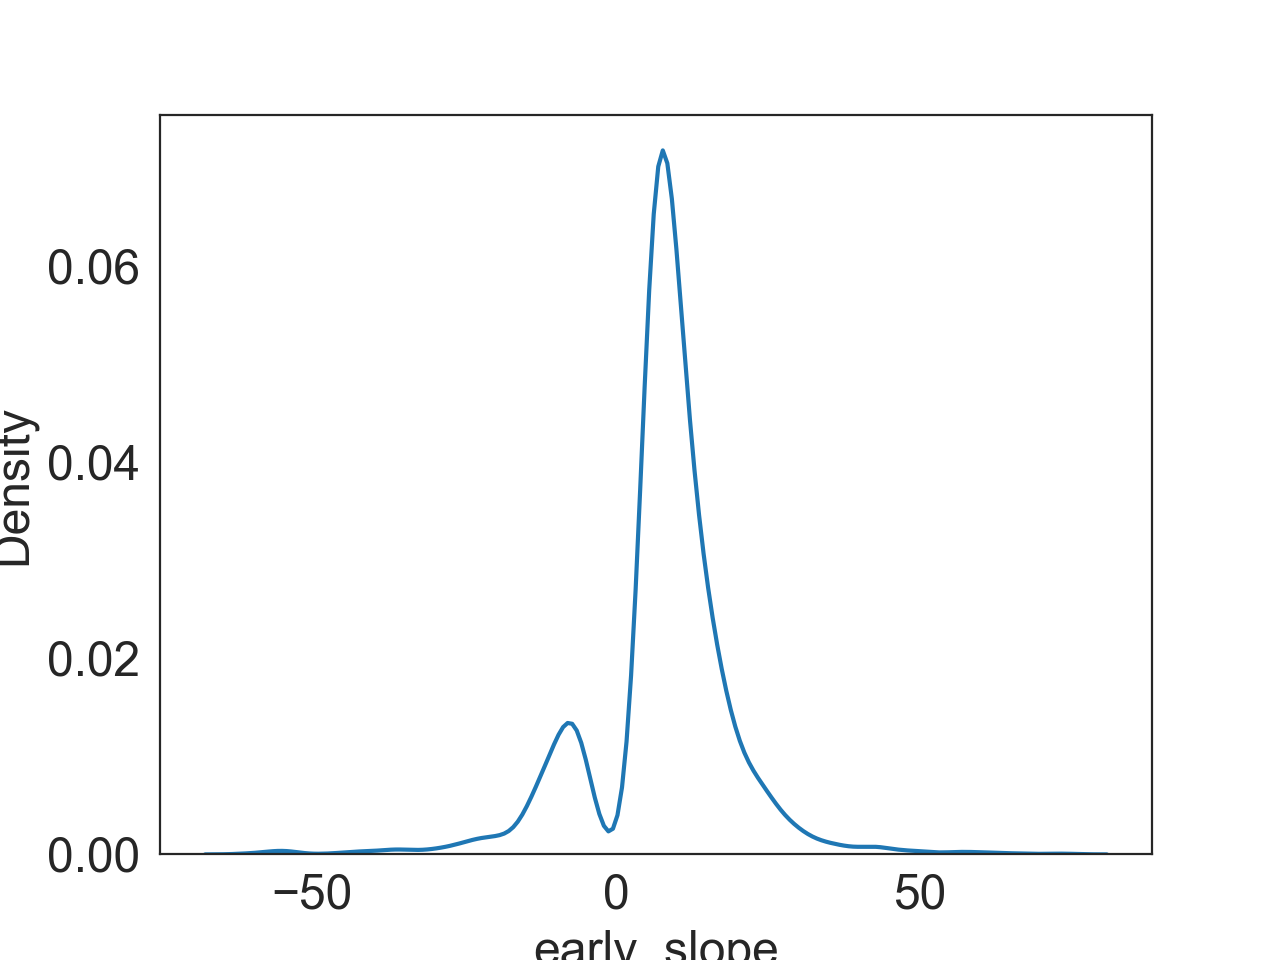

<Axes: xlabel='early_slope', ylabel='Density'>

In [278]:
fig,ax=plt.subplots()

sns.kdeplot(seq_per_image['early_slope'][(seq_per_image['early_slope']>5)|(seq_per_image['early_slope']<-5)])

<IPython.core.display.Javascript object>


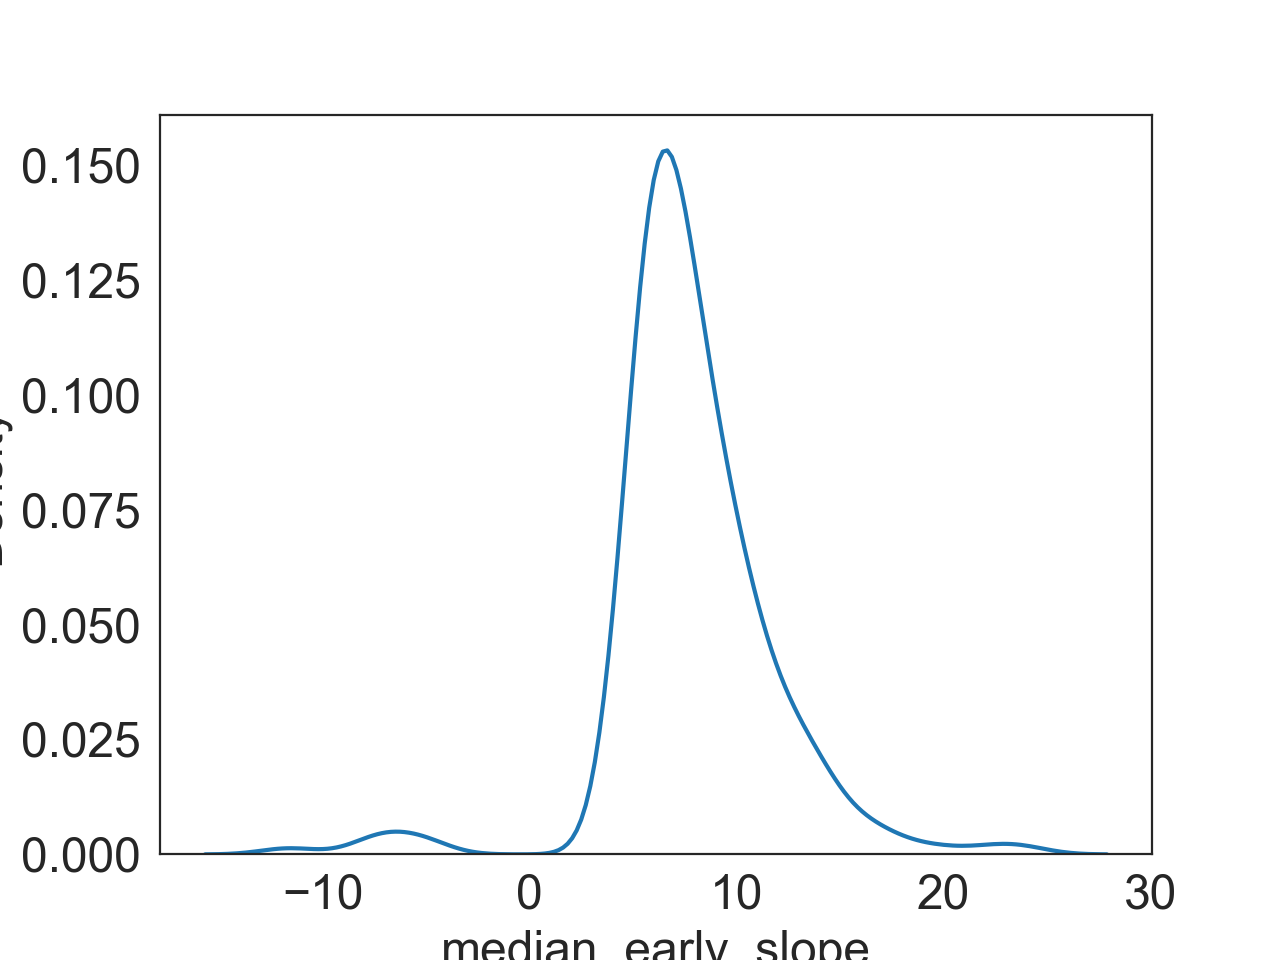

<Axes: xlabel='median_early_slope', ylabel='Density'>

In [279]:
fig,ax=plt.subplots()

sns.kdeplot(seq_summary['median_early_slope'][(seq_summary['median_early_slope']>5)|(seq_summary['median_early_slope']<-5)])

In [280]:
seq_per_image['early_slope'][(seq_per_image['early_slope']>5)|(seq_per_image['early_slope']<-5)]

932     5.767041
2      -8.014560
3     -10.275976
7       7.200501
8      18.656364
         ...    
722     8.679493
723    10.922404
728     6.076900
729     7.451573
734     8.186732
Name: early_slope, Length: 2140, dtype: float64

<IPython.core.display.Javascript object>


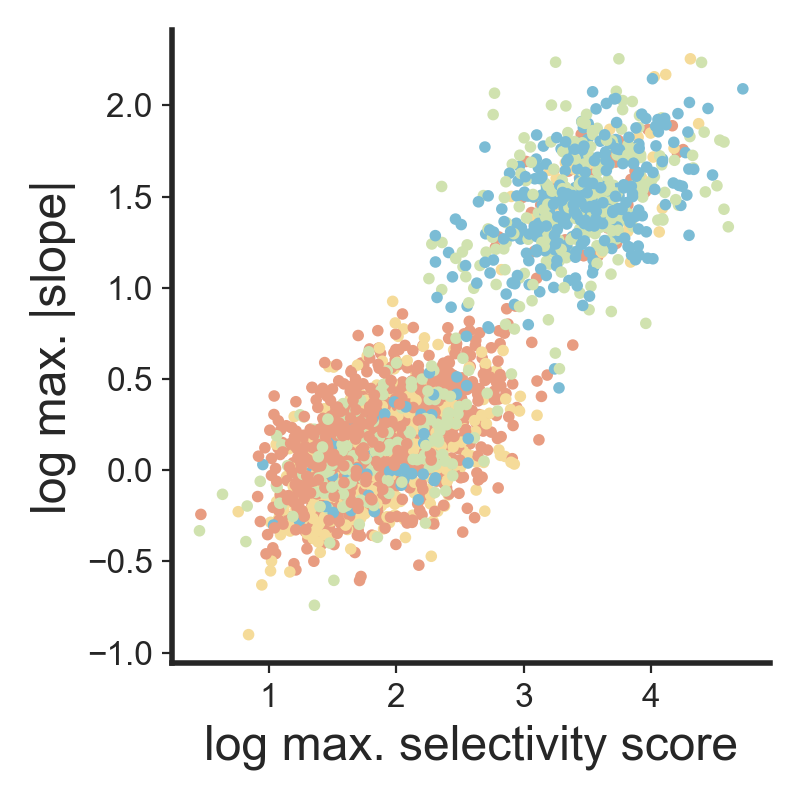

In [281]:
fig,ax=plt.subplots(figsize=(4,4))

sns.despine()

ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

for spine in ['left','bottom']:
    ax.spines[spine].set_linewidth(2)

sc = ax.scatter(np.log10(var),np.log10(slope),c=depth_cols,s=10)
ax.set_xlabel('log max. selectivity score')
ax.set_ylabel('log max. |slope|')
# ax.legend(handles = sc,labels=['25','100','200','250'],frameon=False)
fig.tight_layout()

<IPython.core.display.Javascript object>


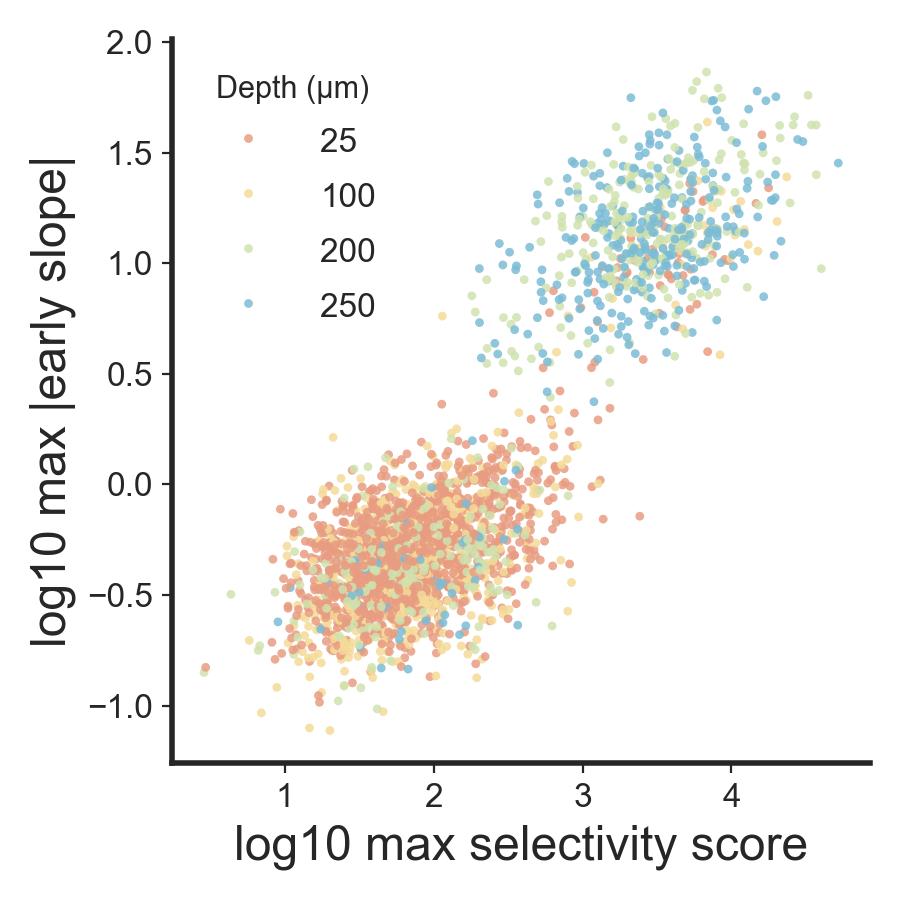

In [282]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

rows = []

palette = {25: cp[0], 100: cp[1], 200: cp[2], 250: cp[3]}

for sess in seq_per_image['session_id'].unique():
    sess_df = seq_per_image[seq_per_image['session_id'] == sess]

    for dmd in sess_df['dmd'].unique():
        dmd_df = sess_df[sess_df['dmd'] == dmd]

        for syn in dmd_df['synapse_id'].unique():
            syn_df = dmd_df[dmd_df['synapse_id'] == syn]

            # current summaries
            max_selectivity = syn_df['image_selectivity_score'].max()
            max_abs_early_slope = np.abs(syn_df['early_slope']).max()

            syn_sum = seq_summary[
                (seq_summary['session_id'] == sess) &
                (seq_summary['synapse_id'] == syn)
            ]

            if syn_sum.empty:
                continue

            if 'DMD1' in syn:
                syn_depth = syn_sum['dmd1_depth'].iloc[0]
            else:
                syn_depth = syn_sum['dmd2_depth'].iloc[0]

            rows.append({
                'session_id': sess,
                'dmd': dmd,
                'synapse_id': syn,
                'depth': syn_depth,
                'max_selectivity': max_selectivity,
                'max_abs_early_slope': max_abs_early_slope,
                'log10_max_selectivity': np.log10(max_selectivity) if max_selectivity > 0 else np.nan,
                'log10_max_abs_early_slope': np.log10(max_abs_early_slope) if max_abs_early_slope > 0 else np.nan,
            })

plot_df = pd.DataFrame(rows).dropna()

fig, ax = plt.subplots(figsize=(4.5, 4.5))
sns.despine(ax=ax)
ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)
sns.scatterplot(
    data=plot_df,
    x='log10_max_selectivity',
    y='log10_max_abs_early_slope',
    hue='depth',
    hue_order=[25, 100, 200, 250],
    palette=palette,
    s=10,
    edgecolor='none',
    alpha=0.85,
    ax=ax,
)

ax.tick_params(axis='x', which='major', top=False, labelsize=12)
ax.tick_params(axis='y', which='major', right=False, labelsize=12)

for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(2)

ax.set_xlabel('log10 max selectivity score')
ax.set_ylabel('log10 max |early slope|')

leg = ax.legend(title='Depth (µm)', frameon=False)
if leg is not None:
    leg.get_title().set_fontsize(11)
    for txt in leg.get_texts():
        txt.set_fontsize(12)
    

fig.tight_layout()

In [289]:
syn_df.loc[syn_df['image_selectivity_score'].idxmin()]

session_id                     838410_2026-03-20_10-00-59
subject_id                                         838410
dmd                                                  DMD2
synapse_id                                   DMD2_syn0012
stimulus_name                stimuli\images_B\216066.tiff
stimulus_label                                     216066
n_positions                                            15
n_sequences                                            42
r0                                               1.891201
rlast                                           -0.229533
rterminal                                        2.311089
terminal_minus_last                              2.540622
early_mean                                       1.521106
late_mean                                        3.667578
early_minus_late                                -2.146473
adaptation_index                                      1.0
sequence_slope                                   0.089876
sequence_slope

In [311]:
rows = []

palette = {25: cp[0], 100: cp[1], 200: cp[2], 250: cp[3]}

for sess in seq_per_image['session_id'].unique():
    sess_df = seq_per_image[seq_per_image['session_id'] == sess]

    for dmd in sess_df['dmd'].unique():
        dmd_df = sess_df[sess_df['dmd'] == dmd]

        for syn in dmd_df['synapse_id'].unique():
            syn_df = dmd_df[dmd_df['synapse_id'] == syn].copy()

            syn_sum = seq_summary[
                (seq_summary['session_id'] == sess) &
                (seq_summary['synapse_id'] == syn)
            ]
            if syn_sum.empty:
                continue

            # preferred image = highest selectivity score
            pref_row = syn_df.loc[syn_df['image_selectivity_score'].idxmax()]
            if 'DMD1' in syn:
                syn_depth = syn_sum['dmd1_depth'].iloc[0]
            else:
                syn_depth = syn_sum['dmd2_depth'].iloc[0]

            rows.append({
                'session_id': sess,
                'dmd': dmd,
                'synapse_id': syn,
                'depth': syn_depth,
                'preferred_selectivity': pref_row['image_selectivity_score'],
                'preferred_early_slope': pref_row['early_slope'],
                'preferred_overall_slope':pref_row['overall_slope'],
                'median_abs_early_slope': np.median(np.abs(syn_df['early_slope'])),
                'mean_abs_early_slope': np.mean(np.abs(syn_df['early_slope'])),
            })

plot_df = pd.DataFrame(rows)

plot_df = plot_df[plot_df['preferred_selectivity'] > 0].copy()
plot_df['log10_preferred_selectivity'] = np.log10(abs(plot_df['preferred_selectivity']))
plot_df['asinh_preferred_early_slope'] = np.arcsinh(plot_df['preferred_early_slope'] / 0.001)
plot_df['asinh_overall_slope'] = np.arcsinh(plot_df['preferred_overall_slope'] / 0.001)

In [312]:
plot_df

,session_id,dmd,synapse_id,depth,preferred_selectivity,preferred_early_slope,preferred_overall_slope,median_abs_early_slope,mean_abs_early_slope,log10_preferred_selectivity,asinh_preferred_early_slope,asinh_overall_slope
0,803496_2025-07-25_13-02-10,DMD1,DMD1_syn0002,25.0,156.407801,0.095214,0.053110,0.181800,0.282139,2.194258,5.249297,4.665599
1,803496_2025-07-25_13-02-10,DMD1,DMD1_syn0003,25.0,112.016762,0.325337,0.267389,0.176696,0.259995,2.049283,6.478011,6.281855
2,803496_2025-07-25_13-02-10,DMD1,DMD1_syn0005,25.0,322.124894,-0.914202,-0.509112,0.374847,0.356827,2.508024,-7.511199,-6.925817
3,803496_2025-07-25_13-02-10,DMD1,DMD1_syn0006,25.0,94.617474,0.590964,0.884095,0.410496,0.427738,1.975971,7.074904,7.477712
4,803496_2025-07-25_13-02-10,DMD1,DMD1_syn0007,25.0,72.895191,-0.150275,0.080727,0.159264,0.240702,1.862699,-5.705622,5.084253
...,...,...,...,...,...,...,...,...,...,...,...,...
2653,838410_2026-03-04_12-54-47,DMD1,DMD1_syn0019,25.0,25.759558,0.073060,0.254898,0.102247,0.107769,1.410938,4.984471,6.234016
2654,838410_2026-03-04_12-54-47,DMD2,DMD2_syn0013,200.0,26.311502,0.295857,0.463712,0.082666,0.113390,1.420146,6.383027,6.832412
2655,838410_2026-03-04_12-54-47,DMD2,DMD2_syn0035,200.0,24.407799,0.334803,0.512317,0.142423,0.140958,1.387529,6.506692,6.932092
2656,838410_2026-03-05_10-16-37,DMD1,DMD1_syn0011,25.0,15.860344,0.213115,0.368267,0.213115,0.201221,1.200313,6.054985,6.601956


<IPython.core.display.Javascript object>


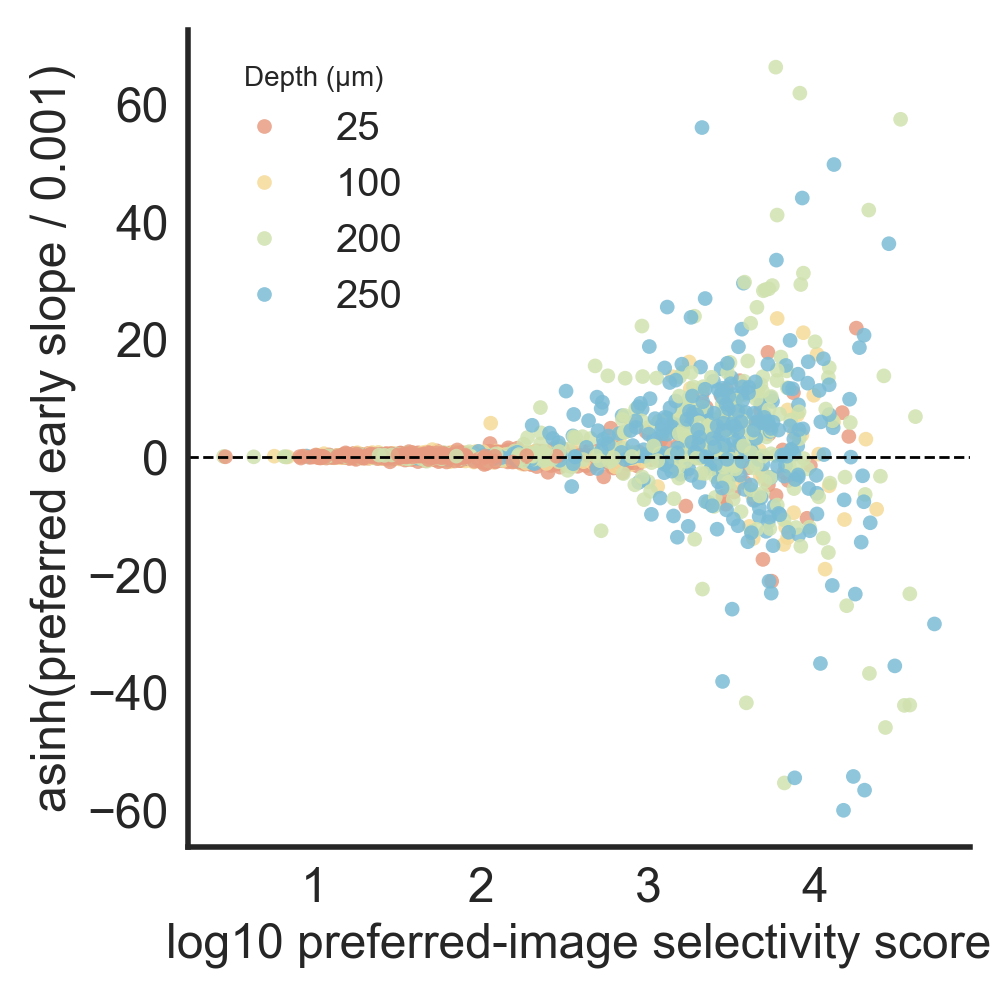

In [317]:
fig, ax = plt.subplots(figsize=(5,5))
sns.despine(ax=ax)

sns.scatterplot(
    data=plot_df,
    x='log10_preferred_selectivity',
    y='preferred_early_slope',
    hue='depth',
    hue_order=[25, 100, 200, 250],
    palette=palette,
    s=28,
    edgecolor='none',
    alpha=0.85,
    ax=ax,
)

ax.axhline(0, color='k', linestyle='--', linewidth=1)
ax.set_xlabel('log10 preferred-image selectivity score')
ax.set_ylabel('asinh(preferred early slope / 0.001)')
ax.legend(title='Depth (µm)', frameon=False)

for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(2)

fig.tight_layout()

In [141]:
plot_df

,session_id,dmd,synapse_id,depth,preferred_selectivity,preferred_early_slope,preferred_overall_slope,median_abs_early_slope,mean_abs_early_slope,log10_preferred_selectivity,asinh_preferred_early_slope,asinh_overall_slope
0,803496_2025-07-25_13-02-10,DMD1,DMD1_syn0002,25.0,156.407801,0.095214,0.053110,0.181800,0.282139,2.194258,5.249297,4.665599
1,803496_2025-07-25_13-02-10,DMD1,DMD1_syn0003,25.0,112.016762,0.325337,0.267389,0.176696,0.259995,2.049283,6.478011,6.281855
2,803496_2025-07-25_13-02-10,DMD1,DMD1_syn0005,25.0,322.124894,-0.914202,-0.509112,0.374847,0.356827,2.508024,-7.511199,-6.925817
3,803496_2025-07-25_13-02-10,DMD1,DMD1_syn0006,25.0,94.617474,0.590964,0.884095,0.410496,0.427738,1.975971,7.074904,7.477712
4,803496_2025-07-25_13-02-10,DMD1,DMD1_syn0007,25.0,72.895191,-0.150275,0.080727,0.159264,0.240702,1.862699,-5.705622,5.084253
...,...,...,...,...,...,...,...,...,...,...,...,...
2653,838410_2026-03-04_12-54-47,DMD1,DMD1_syn0019,25.0,25.759558,0.073060,0.254898,0.102247,0.107769,1.410938,4.984471,6.234016
2654,838410_2026-03-04_12-54-47,DMD2,DMD2_syn0013,200.0,26.311502,0.295857,0.463712,0.082666,0.113390,1.420146,6.383027,6.832412
2655,838410_2026-03-04_12-54-47,DMD2,DMD2_syn0035,200.0,24.407799,0.334803,0.512317,0.142423,0.140958,1.387529,6.506692,6.932092
2656,838410_2026-03-05_10-16-37,DMD1,DMD1_syn0011,25.0,15.860344,0.213115,0.368267,0.213115,0.201221,1.200313,6.054985,6.601956


<IPython.core.display.Javascript object>


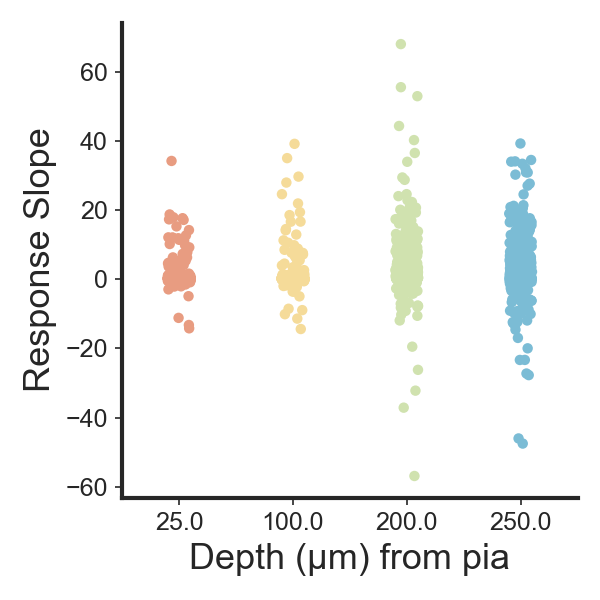

In [174]:
fig,ax=plt.subplots(figsize=(4,4))

sns.despine()

ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

sns.stripplot(data=plot_df,x='depth',y='preferred_overall_slope',hue='depth',palette=cp,legend=False)

ax.set_xlabel('Depth (\u03BCm) from pia')
ax.set_ylabel('Response Slope')

for spine in ['left','bottom']:
    ax.spines[spine].set_linewidth(2)

fig.tight_layout()

In [318]:
responses25 = []
responses100 = []
responses200 = []
responses250 = []

depth_map = {25:cp[0],100:cp[1],200:cp[2],250:cp[3]}

for sess in seq_per_image['session_id'].unique():
    sess_df = seq_per_image[seq_per_image['session_id']==sess]
    
    for dmd in sess_df['dmd'].unique():
        dmd_df = sess_df[sess_df['dmd']==dmd]
        
        for syn in dmd_df['synapse_id'].unique():
            syn_df = dmd_df[dmd_df['synapse_id']==syn].sort_values('overall_slope')
            
            syn_sum = seq_summary[(seq_summary['session_id']==sess)&(seq_summary['synapse_id']==syn)]
            
            if 'DMD1' in syn:
                syn_depth = syn_sum['dmd1_depth'].values[0]
            else:
                syn_depth = syn_sum['dmd2_depth'].values[0]
                
#             depth_cols.append(depth_map[syn_depth])
            if syn_depth == 25:
                responses25.append(syn_df['overall_slope'].values)
            elif syn_depth == 100:
                responses100.append(syn_df['overall_slope'].values)
            elif syn_depth == 200:
                responses200.append(syn_df['overall_slope'].values)
            elif syn_depth == 250:
                responses250.append(syn_df['overall_slope'].values)

In [326]:
np.sort?

<IPython.core.display.Javascript object>


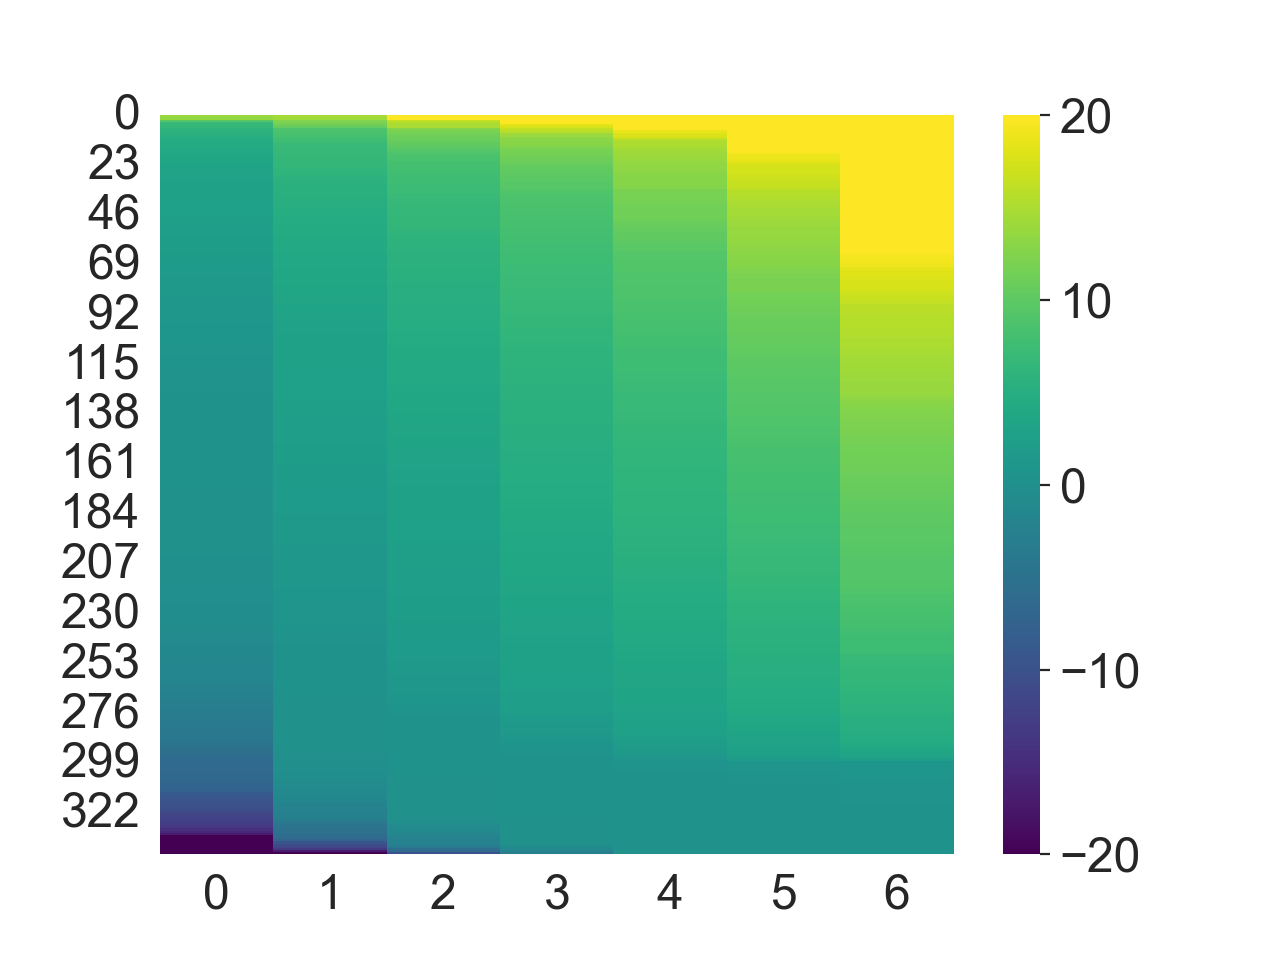

<Axes: >

In [342]:
fig,ax=plt.subplots()

sns.heatmap(np.sort(responses250,axis=0)[::-1],vmin=-20,vmax=20,cmap='viridis')

In [153]:
example = np.array(seq_per_image[seq_per_image['synapse_id']==syn].sort_values('overall_slope')['overall_slope'])

<IPython.core.display.Javascript object>


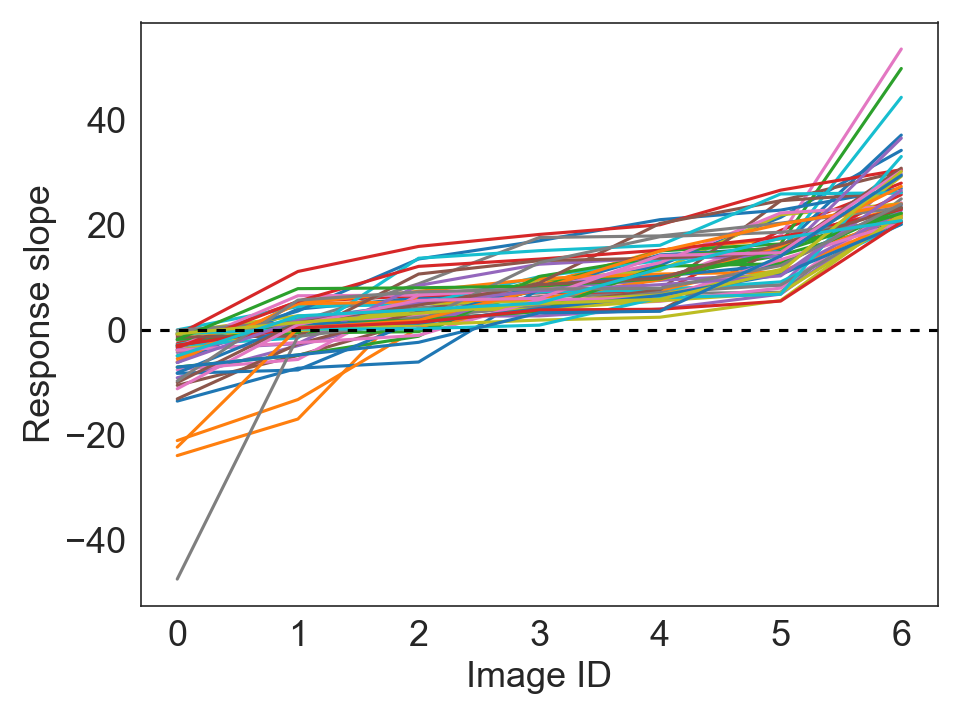

In [173]:
fig,ax = plt.subplots()

for synapse in responses:
    if synapse[0]<0 and synapse[-1]>20:
        ax.plot(synapse)
ax.set_ylabel('Response slope')
ax.set_xlabel('Image ID')
ax.axhline(0,dashes=[3,3],color='k')
fig.tight_layout()

In [259]:
responses = []

depth_map = {25:cp[0],100:cp[1],200:cp[2],250:cp[3]}

for sess in seq_per_image['session_id'].unique():
    sess_df = seq_per_image[seq_per_image['session_id']==sess]
    
    for dmd in sess_df['dmd'].unique():
        dmd_df = sess_df[sess_df['dmd']==dmd]
        
        for syn in dmd_df['synapse_id'].unique():
            syn_df = dmd_df[dmd_df['synapse_id']==syn].sort_values('overall_slope')
            responses.append(syn_df.iloc[:][['r0','rlast','rterminal']].values)
            

<IPython.core.display.Javascript object>


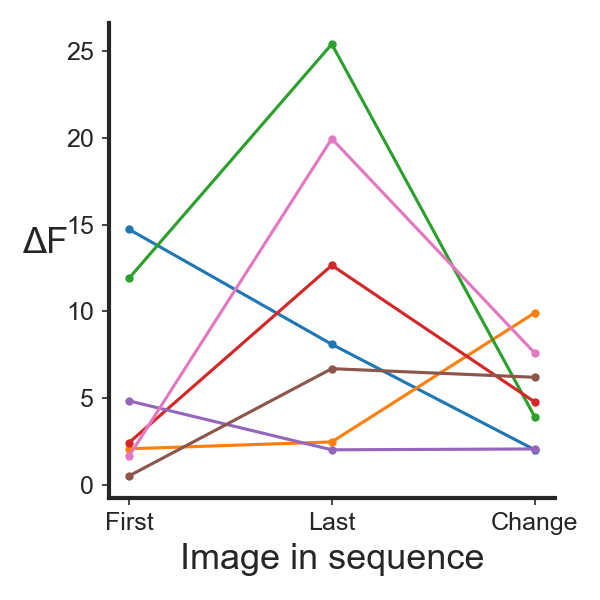

In [270]:
fig,ax=plt.subplots(figsize=(4,4))

sns.despine()

ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

for spine in ['left','bottom']:
    ax.spines[spine].set_linewidth(2)
    
for r in responses[9]:
    ax.plot(r,marker='.')
    
ax.set_xticks([0,1,2])
ax.set_xticklabels(['First','Last','Change'])

ax.set_ylabel('\u0394F', rotation=0, labelpad=10)
ax.set_xlabel('Image in sequence')

# ax.set_title()

fig.tight_layout()

<IPython.core.display.Javascript object>


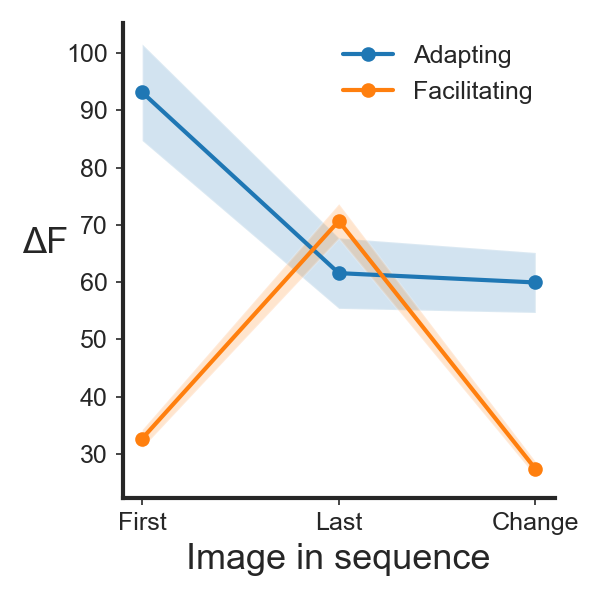

In [256]:
fig,ax=plt.subplots(figsize=(4,4))

sns.despine()

ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

for spine in ['left','bottom']:
    ax.spines[spine].set_linewidth(2)
    
# for syn in responses:
#     for r in syn:
#         ax.plot(r,marker='.')

adapting = []
facilitating = []
for r in responses:
    if r[1]<r[0]:
        adapting.append(r)
    else:
        facilitating.append(r)
        
f_mean = np.mean(facilitating,axis=0)
f_sem = [np.std(np.array(facilitating)[:,i])/np.sqrt(len(facilitating)) for i in range(np.shape(facilitating)[1])]
a_mean = np.mean(adapting,axis=0)
a_sem = [np.std(np.array(adapting)[:,i])/np.sqrt(len(adapting)) for i in range(np.shape(adapting)[1])]

ax.plot(a_mean,label='Adapting',marker='o',lw=2)
ax.fill_between(np.arange(3),list(a_mean-a_sem),list(a_mean+a_sem),alpha=0.2,zorder=0)
ax.plot(f_mean,label='Facilitating',marker='o',lw=2)
ax.fill_between(np.arange(3),list(f_mean-f_sem),list(f_mean+f_sem),alpha=0.2,zorder=0)

    
ax.set_xticks([0,1,2])
ax.set_xticklabels(['First','Last','Change'])

ax.set_ylabel('\u0394F', rotation=0, labelpad=10)
ax.set_xlabel('Image in sequence')

ax.legend(frameon=False,fontsize=12)
fig.tight_layout()

In [343]:
len(responses25)

1265

In [344]:
len(responses100)

656

In [345]:
len(responses200)

396

In [346]:
len(responses250)

341